<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/LangChain(Runnables%7CPipelines).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q langchain langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.0/570.0 kB 19.2 MB/s eta 0:00:00


In [4]:
from IPython.display import Image
from google.colab import userdata
from langchain.messages import AIMessage, HumanMessage
from langchain_core.messages import BaseMessage
from langchain_core.runnables import Runnable, RunnablePassthrough
from langchain_openai import ChatOpenAI
from pathlib import Path
from pydantic import SecretStr

def print_response(response: BaseMessage):
    print(f"Response id: {response.id}")
    if response.usage_metadata is not None:
        input_tokens = response.usage_metadata.get("input_tokens", 0)
        cached_tokens = response.usage_metadata.get("input_token_details", {}).get("cache_read", 0)
        output_tokens = response.usage_metadata.get("output_tokens", 0)
        reasoning_tokens = response.usage_metadata.get("output_token_details", {}).get("reasoning", 0)

        print(f"Input tokens: {input_tokens} ({cached_tokens} cached); Output tokens: {output_tokens} ({reasoning_tokens}) reasoning")

        print()
        print(f"{'-'*20} [Output] {'-'*20}")
        print(response.text)

def display_graph(runnable: Runnable, output_png: Path) -> None:
    graph = runnable.get_graph()

    with output_png.open(mode = "wb") as file:
        file.write(graph.draw_mermaid_png())

    display(Image(output_png, format = "png"))

In [5]:
openai_api_key = SecretStr(userdata.get('OPENAI_API_KEY'))
openai_model = ChatOpenAI(model="gpt-5-nano", api_key = openai_api_key, reasoning_effort="low")

## изграждаме един chain, pipeline или последователност от Runnables:
- взамаме един runnable пайпваме го | с друг ръннабъл с втори, с трети и т.н.

Ако тръгнем да изпълняваме този chain:
  - inputa влиза в първият runnable, първият runnable върши каквото върши и накрая генерира first_output - това е междинене output, който го приемаме за input за следващият runnable.
    
    input -> first_runnable -> first_output/input-> second_runnable

    Този chain дава възможност да подадем списък от съобщения

    виж за RunnablePassthrough.assign - в случаите когато искаме да обогатим input-a добавяйки още някакави записи в него

In [7]:
chain = RunnablePassthrough(lambda _: print("Start model execution")) | openai_model | RunnablePassthrough(lambda _: print("Model execution finished")) | RunnablePassthrough(print_response)

In [8]:
conversation = [HumanMessage("Hello, How are you?")]
result = chain.invoke(conversation)

Start model execution
Model execution finished
Response id: lc_run--01a01f96-040e-7aa3-ab5e-525bab35a381-0
Input tokens: 12 (0 cached); Output tokens: 43 (0) reasoning

-------------------- [Output] --------------------
Hi! I’m doing well, thanks. How can I help you today? If you’d like, tell me what you’re working on or any question you have.


In [11]:
result

AIMessage(content='Hi! I’m doing well, thanks. How can I help you today? If you’d like, tell me what you’re working on or any question you have.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 12, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EEy6DOgOagxsiuQUFtoP65M7og7WC', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01f96-040e-7aa3-ab5e-525bab35a381-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 43, 'total_tokens': 55, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoni

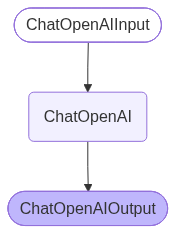

In [9]:
display_graph(openai_model, Path('/content/model.png'))

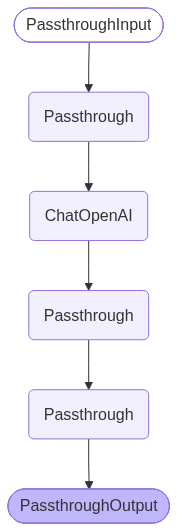

In [10]:
display_graph(chain, Path("/content/chain.png"))